<a href="https://colab.research.google.com/github/TimotheeeNiven/KDThesis/blob/main/FullTrainingExample/Cifar100KnowledgeDistilation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from tensorflow.keras import layers, regularizers
import time

In [ ]:
dist_epochs    = 50
teacher_epochs = 75
student_epochs = 50

batch_size = 64
train_teacher = False
save_teacher = False # only recognized if train_teacher == True

dataset = "CIFAR100"

alpha = 0.0

In [ ]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        """ Configure the distiller.
        Args:
            optimizer: Keras optimizer for the student weights
            metrics: Keras metrics for evaluation
            student_loss_fn: Loss function of difference between student
                predictions and ground-truth
            distillation_loss_fn: Loss function of difference between soft
                student predictions and soft teacher predictions
            alpha: weight to student_loss_fn and 1-alpha to distillation_loss_fn
            temperature: Temperature for softening probability distributions.
                Larger temperature gives softer distributions.
        """
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        # Unpack data
        x, y = data

        # Forward pass of teacher
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            # Forward pass of student
            student_predictions = self.student(x, training=True)

            # Compute losses
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
            #^^ mixing coeff.        ^^ wrt true labels                  ^^ error wrt teacher labels

        # Compute gradients
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Update weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the metrics configured in `compile()`.
        self.compiled_metrics.update_state(y, student_predictions)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update(
            {"student_loss": student_loss, "distillation_loss": distillation_loss}
        )
        return results

    def test_step(self, data):
        # Unpack the data
        x, y = data

        # Compute predictions
        y_prediction = self.student(x, training=False)

        # Calculate the loss
        student_loss = self.student_loss_fn(y, y_prediction)

        # Update the metrics.
        self.compiled_metrics.update_state(y, y_prediction)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

tf.nn.softmax(np.array([.5, .050])).numpy()

array([0.61063923, 0.38936077])

In [ ]:
if dataset == "CIFAR10":
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
    y_train = y_train.squeeze()
    y_test = y_test.squeeze()
    # scale??
elif dataset == "CIFAR100":
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()
    class_names = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']
    y_train = y_train.squeeze()
    y_test = y_test.squeeze()
    # scale??
else:
    raise ValueError("Invalid dataset name. Please specify either 'CIFAR10' or 'CIFAR100'.")

print("Maximum pixel value in x_train:", np.max(x_train))


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Maximum pixel value in x_train: 255


In [ ]:
# Create the teacher
teacher = keras.Sequential([
    keras.Input(shape=x_train[0].shape),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same"),
    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same"),
    layers.Dropout(0.2),
    layers.Conv2D(512, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same"),
    layers.Dropout(0.32),
    layers.GlobalAveragePooling2D(),
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Dense(100),  # Adjusted for CIFAR-100, 100 classes
], name="teacher")

# Summary of the teacher model
teacher.summary()


Model: "teacher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          25,700 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 1,707,364 (6.51 MB)

 Trainable params: 1,704,548 (6.50 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
def build_student_model_v2(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(16, kernel_size=(3,3), strides=(2,2), activation="relu", padding='same')(inputs)
    y = layers.BatchNormalization()(x)  # save the result in y for the skip connection
    x = layers.SeparableConv2D(32, kernel_size=(3,3), strides=(2,2), activation="relu", padding='same')(y)
    x = layers.BatchNormalization()(x)
    x = layers.SeparableConv2D(64, kernel_size=(3,3), strides=(2,2), activation="relu", padding='same')(x)
    x = layers.BatchNormalization()(x)
    # match the channel counts for the skip ADD.
    y = layers.Conv2D(64, kernel_size=(1,1), strides=(4,4))(y)
    y = layers.add((x, y))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(100)(x)  # Adjusted for CIFAR-100, 100 classes

    model = keras.Model(inputs, outputs)

    return model


In [ ]:
# Create the student
student = build_student_model_v2(x_train[0].shape)

# Clone student for later comparison
student_scratch = keras.models.clone_model(student)

In [ ]:
teacher.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

# Train the model
start_time = time.time()
history = teacher.fit(x_train, y_train, epochs=40, batch_size=32, validation_data=(x_test, y_test))
teacher_training_time = time.time() - start_time

# Evaluate the model
test_loss, test_acc = teacher.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

Epoch 1/40
1563/1563 [==============================] - 33s 15ms/step - loss: 3.4354 - accuracy: 0.1799 - val_loss: 3.6646 - val_accuracy: 0.1602
Epoch 2/40
1563/1563 [==============================] - 21s 13ms/step - loss: 2.6307 - accuracy: 0.3257 - val_loss: 3.0249 - val_accuracy: 0.2848
Epoch 3/40
1563/1563 [==============================] - 21s 13ms/step - loss: 2.2734 - accuracy: 0.3998 - val_loss: 2.3778 - val_accuracy: 0.3829
Epoch 4/40
1563/1563 [==============================] - 21s 14ms/step - loss: 2.0400 - accuracy: 0.4501 - val_loss: 2.6311 - val_accuracy: 0.3612
Epoch 5/40
1563/1563 [==============================] - 21s 13ms/step - loss: 1.8630 - accuracy: 0.4887 - val_loss: 2.1182 - val_accuracy: 0.4420
Epoch 6/40
1563/1563 [==============================] - 21s 13ms/step - loss: 1.7249 - accuracy: 0.5226 - val_loss: 2.1407 - val_accuracy: 0.4376
Epoch 7/40
1563/1563 [==============================] - 21s 13ms/step - loss: 1.6028 - accuracy: 0.5518 - val_loss: 1.9528 -

In [ ]:
teacher.save("teacher_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Initialize and compile distiller
distiller = Distiller(student=student, teacher=teacher)
distiller.compile(
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=alpha,
    temperature=10,
)

In [ ]:
# Distill teacher to student
start_time = time.time()
dist_hist = distiller.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test))
distilled_training_time = time.time() - start_time

Epoch 1/50
1563/1563 [==============================] - 19s 8ms/step - sparse_categorical_accuracy: 0.0872 - student_loss: 4.5752 - distillation_loss: 0.1413 - val_sparse_categorical_accuracy: 0.1239 - val_student_loss: 4.9398
Epoch 2/50
1563/1563 [==============================] - 12s 8ms/step - sparse_categorical_accuracy: 0.1501 - student_loss: 4.4054 - distillation_loss: 0.1174 - val_sparse_categorical_accuracy: 0.1696 - val_student_loss: 5.4659
Epoch 3/50
1563/1563 [==============================] - 15s 10ms/step - sparse_categorical_accuracy: 0.1801 - student_loss: 4.2258 - distillation_loss: 0.1086 - val_sparse_categorical_accuracy: 0.1914 - val_student_loss: 3.8151
Epoch 4/50
1563/1563 [==============================] - 14s 9ms/step - sparse_categorical_accuracy: 0.2003 - student_loss: 4.1110 - distillation_loss: 0.1037 - val_sparse_categorical_accuracy: 0.1981 - val_student_loss: 4.9158
Epoch 5/50
1563/1563 [==============================] - 12s 8ms/step - sparse_categorical_a

In [ ]:
student_scratch.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
# Train the model
start_time = time.time()
history = student_scratch.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
student_training_time = time.time() - start_time

Epoch 1/10
1563/1563 [==============================] - 13s 7ms/step - loss: 3.9214 - accuracy: 0.1003 - val_loss: 3.6303 - val_accuracy: 0.1433
Epoch 2/10
1563/1563 [==============================] - 10s 6ms/step - loss: 3.4492 - accuracy: 0.1735 - val_loss: 4.5775 - val_accuracy: 0.0884
Epoch 3/10
1563/1563 [==============================] - 11s 7ms/step - loss: 3.2371 - accuracy: 0.2106 - val_loss: 3.1703 - val_accuracy: 0.2251
Epoch 4/10
1563/1563 [==============================] - 10s 7ms/step - loss: 3.1104 - accuracy: 0.2357 - val_loss: 3.0984 - val_accuracy: 0.2440
Epoch 5/10
1563/1563 [==============================] - 10s 6ms/step - loss: 3.0128 - accuracy: 0.2559 - val_loss: 3.0589 - val_accuracy: 0.2473
Epoch 6/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.9364 - accuracy: 0.2702 - val_loss: 2.9140 - val_accuracy: 0.2749
Epoch 7/10
1563/1563 [==============================] - 10s 7ms/step - loss: 2.8797 - accuracy: 0.2795 - val_loss: 3.0959 - val_ac

In [ ]:
# Evaluate the model
test_loss, test_acc = student_scratch.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 [==============================] - 1s 3ms/step - loss: 2.8537 - accuracy: 0.2882
Test accuracy: 0.2881999909877777


In [ ]:
# Evaluate distilled student on test dataset
[dist_acc, dist_loss] = distiller.evaluate(x_test[:], y_test[:])
print(f"Distilled model accuracy: {dist_acc}, loss: {dist_loss}")

313/313 [==============================] - 1s 4ms/step - sparse_categorical_accuracy: 0.2967 - student_loss: 3.5834
Distilled model accuracy: 0.29670000076293945, loss: 2.922110080718994


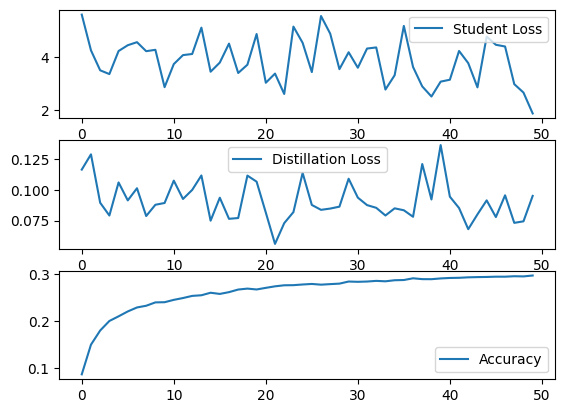

In [ ]:
# Evaluate the teacher model
teacher_test_loss, teacher_test_acc = teacher.evaluate(x_test, y_test)
print(f"Teacher Model:")
print(f"  Test accuracy: {teacher_test_acc}")
print(f"  Test loss: {teacher_test_loss}")
print(f"  Training time: {teacher_training_time:.2f} seconds")


# Evaluate the student model
student_scratch_test_loss, student_scratch_test_acc = student_scratch.evaluate(x_test, y_test)
print(f"\nStudent Model:")
print(f"  Test accuracy: {student_scratch_test_acc}")
print(f"  Test loss: {student_scratch_test_loss}")
print(f"  Training time: {student_training_time:.2f} seconds")

# Evaluate the distilled model
dist_acc, dist_loss = distiller.evaluate(x_test, y_test)
print(f"\nDistilled Model:")
print(f"  Test accuracy: {dist_acc}")
print(f"  Test loss: {dist_loss}")
print(f"  Training time: {distilled_training_time:.2f} seconds")

# Print training details for each model
print("\nTraining Details:")
print(f"Teacher Model Training Time: {teacher_training_time:.2f} seconds")
print(f"Student Model Training Time: {student_training_time:.2f} seconds")
print(f"Distilled Model Training Time: {distilled_training_time:.2f} seconds")